# produce_images
Driver notebook for `dqm_plot.py`.  
All configuration lives here; core logic lives in `dqm_plot.py`.

**Image naming convention:** `<subsystem>_<plotNumber>_<titleSlug>[_grpN]_run<XXXXXX>.png`

- `subsystem`  — from `shift_layouts.json` (e.g. `L1T`, `Ecal`, `P5_Cosmics`)
- `plotNumber` — leading token of the plot title (e.g. `11`, `05`, `A`)
- `titleSlug`  — title with the number prefix stripped and all non-alphanumeric characters removed (e.g. `RecHitEnergy`, `uGMTmuonetaphi`)
- `grpN`       — added only when multiple plots share the same title (e.g. `grp0`, `grp1`, `grp2`); omitted when the plot is unique within its number
- `runNumber`  — zero-padded 6-digit run number

**Output layout:**
```
images/
    <subsystem>_<plotNumber>_<titleSlug>/     ← one folder per plot slot
        <stem>[_grpN]_run<XXXXXX>.png         ← one file per subplot × run
    ref/
        <stem>[_grpN]_run<XXXXXX>.png         ← reference / "good example" images
```

**Examples:**
```
images/Ecal_05_RecHitEnergy/Ecal_05_RecHitEnergy_grp0_run398185.png   ← subplot (same title × 3 paths)
images/L1T_11_uGMTmuonetaphi/L1T_11_uGMTmuonetaphi_run398185.png     ← unique plot
images/ref/Ecal_05_RecHitEnergy_grp0_run398185.png                    ← reference image
```

In [ ]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd()))
from dqm_plot import produce_images, expand_files
from shift_layout_helpers import (
    list_subsystems, list_plots,
    build_image_config, format_image_config,
    lookup_by_stem,
    # legacy helpers (still available)
    build_plot_config, format_plot_config,
)

print('dqm_plot loaded OK')

## Browse available plots

Use `shift_layout_helpers` to explore `shift_layouts.json` and build `PLOT_CONFIG` entries.

In [ ]:
# List all subsystems in shift_layouts.json
list_subsystems()

In [ ]:
# List plots for a subsystem (set with_descriptions=True for path + description)
list_plots("L1T", with_descriptions=False)

In [ ]:
# Show stems, folders, and ROOT paths for a subsystem — copy/trim as needed
format_image_config("L1T")

In [3]:
# ── Input files ───────────────────────────────────────────────────────────────
# Accepts any mix of:
#   - Exact XRootD URLs
#   - XRootD glob patterns  (resolved via xrdfs ls)
#   - Exact local paths
#   - Local glob patterns   (shell-style *)

FILE_PATTERNS = [
    # XRootD glob — all L1T DQM files in a directory
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_*.root",

    # Exact files
    # "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398185.root",
    # "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398200.root",

    # Local files
    # "/data/DQM/DQM_V0001_L1T_R000398185.root",
    # "/data/DQM/DQM_V0001_L1T_*.root",
]

# Preview what expand_files() will resolve
resolved = expand_files(FILE_PATTERNS)
print(f'{len(resolved)} file(s) found:')
for f in resolved:
    print(f'  {f}')

8 file(s) found:
  root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398185.root
  root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398186.root
  root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398187.root
  root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398188.root
  root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398189.root
  root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398191.root
  root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398194.root
  root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398199.root


In [ ]:
# ── Plot configuration ────────────────────────────────────────────────────────
# Option A: all plots for a subsystem (recommended)
IMAGE_CONFIG = build_image_config("L1T")

# Option B: hand-pick specific plots from the list above
# IMAGE_CONFIG = [s for s in build_image_config("L1T") if s["plot_number"] in ("00", "11")]

# ── Output options ────────────────────────────────────────────────────────────
OUTDIR = 'images'
WIDTH  = 900
HEIGHT = 700

# Force a run number for all files (leave None to auto-detect from filename)
RUN_OVERRIDE = None
# RUN_OVERRIDE = '398185'

print(f'Plots configured : {len(IMAGE_CONFIG)}')
for s in IMAGE_CONFIG:
    print(f'  {s["stem"]}  →  {s["folder"]}/  (root: .../{s["path"].split("/")[-1]})')
print(f'\nTotal images     : {len(expand_files(FILE_PATTERNS)) * len(IMAGE_CONFIG)}')

In [ ]:
# ── Produce images ────────────────────────────────────────────────────────────
results = produce_images(
    file_patterns=FILE_PATTERNS,
    plot_config=IMAGE_CONFIG,
    outdir=OUTDIR,
    run_override=RUN_OVERRIDE,
    width=WIDTH,
    height=HEIGHT,
    verbose=True,
)

In [7]:
# ── Summary ───────────────────────────────────────────────────────────────────
df = pd.DataFrame(results)
df['filename'] = df['root_file'].apply(lambda p: Path(p).name)

errors = df[df['error'].notna()]
if not errors.empty:
    print(f'WARNING: {len(errors)} failed:')
    display(errors[['run', 'plot_name', 'filename', 'error']])
else:
    print('All images produced successfully.')

print()
display(df[['run', 'plot_name', 'filename', 'out_png', 'error']])

All images produced successfully.



,run,plot_name,filename,out_png,error
0,398185,ecalOccRecdEtWgt,DQM_V0001_L1T_R000398185.root,images/ecalOccRecdEtWgt/ecalOccRecdEtWgt_run39...,None
1,398186,ecalOccRecdEtWgt,DQM_V0001_L1T_R000398186.root,images/ecalOccRecdEtWgt/ecalOccRecdEtWgt_run39...,None
2,398187,ecalOccRecdEtWgt,DQM_V0001_L1T_R000398187.root,images/ecalOccRecdEtWgt/ecalOccRecdEtWgt_run39...,None
3,398188,ecalOccRecdEtWgt,DQM_V0001_L1T_R000398188.root,images/ecalOccRecdEtWgt/ecalOccRecdEtWgt_run39...,None
4,398189,ecalOccRecdEtWgt,DQM_V0001_L1T_R000398189.root,images/ecalOccRecdEtWgt/ecalOccRecdEtWgt_run39...,None
5,398191,ecalOccRecdEtWgt,DQM_V0001_L1T_R000398191.root,images/ecalOccRecdEtWgt/ecalOccRecdEtWgt_run39...,None
6,398194,ecalOccRecdEtWgt,DQM_V0001_L1T_R000398194.root,images/ecalOccRecdEtWgt/ecalOccRecdEtWgt_run39...,None
7,398199,ecalOccRecdEtWgt,DQM_V0001_L1T_R000398199.root,images/ecalOccRecdEtWgt/ecalOccRecdEtWgt_run39...,None


ecalOccRecdEtWgt  run=398185


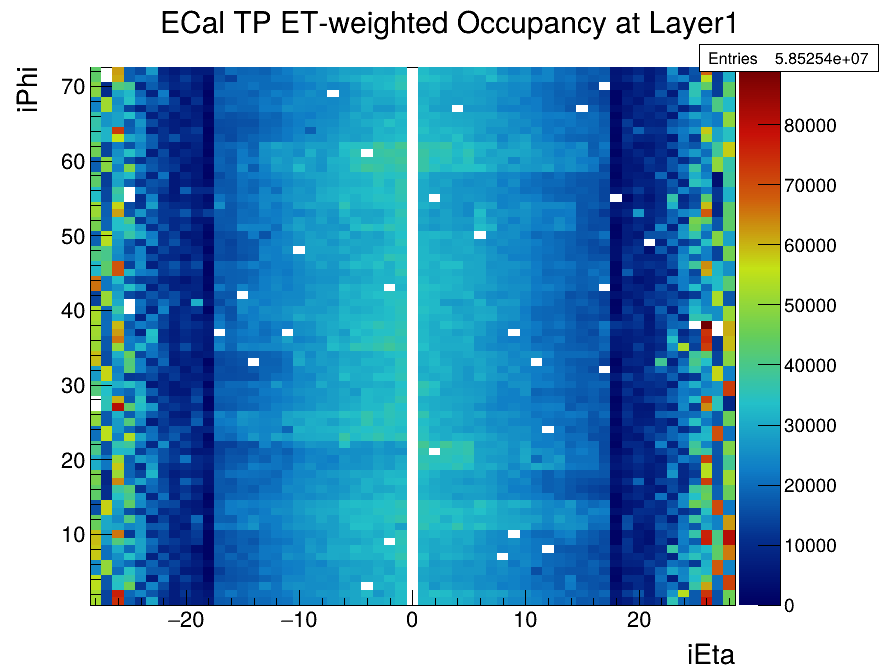


ecalOccRecdEtWgt  run=398186


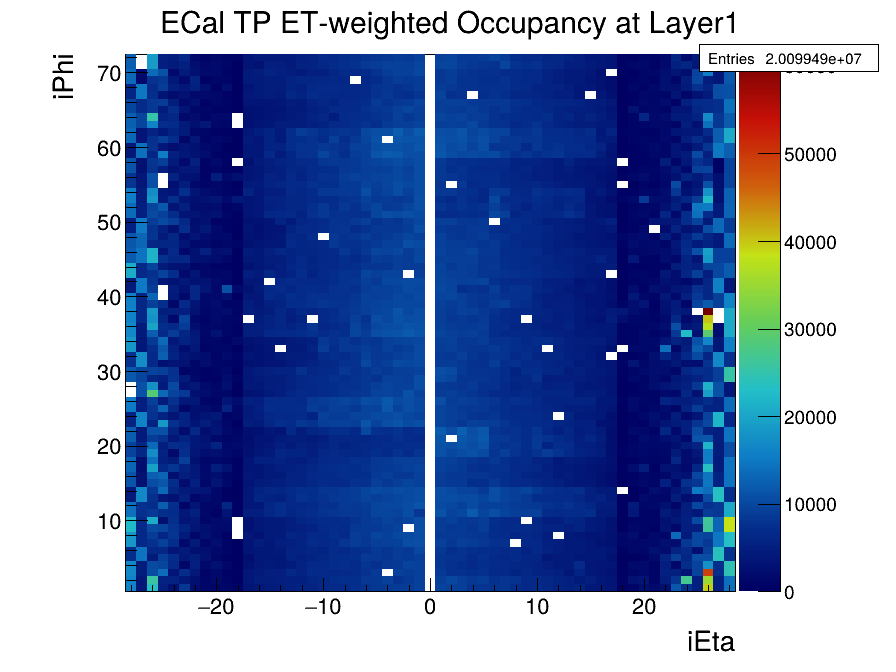


ecalOccRecdEtWgt  run=398187


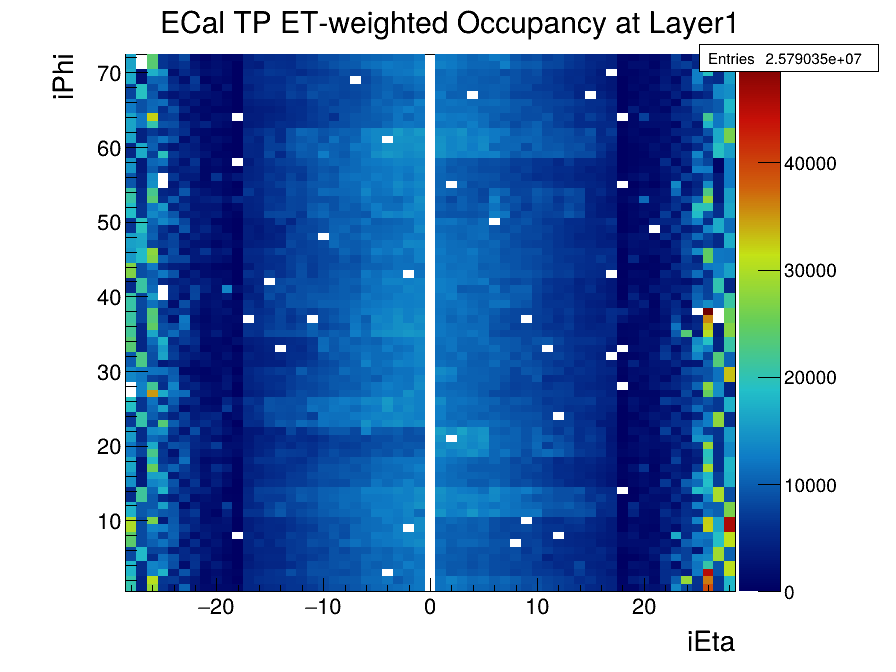


ecalOccRecdEtWgt  run=398188


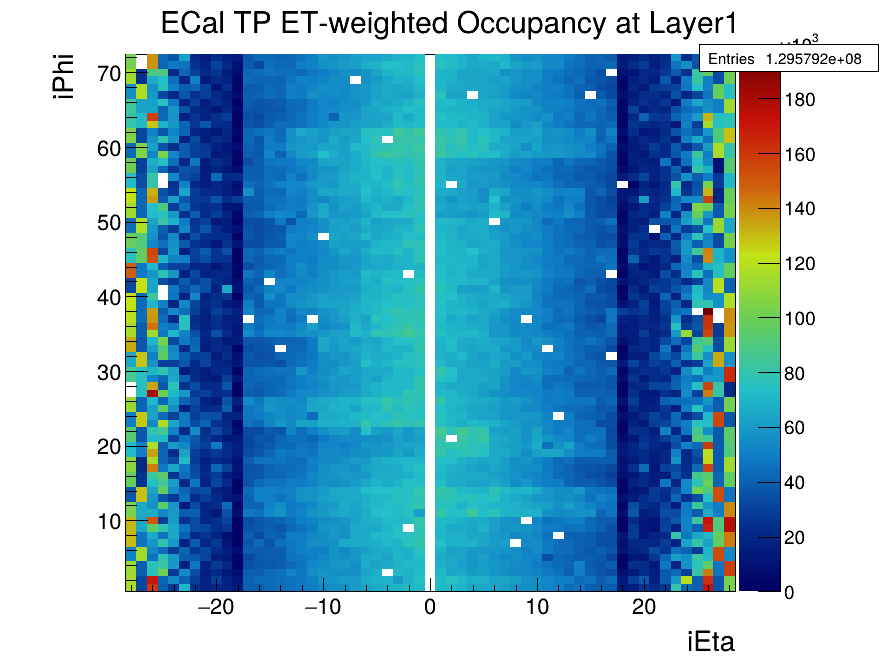


ecalOccRecdEtWgt  run=398189


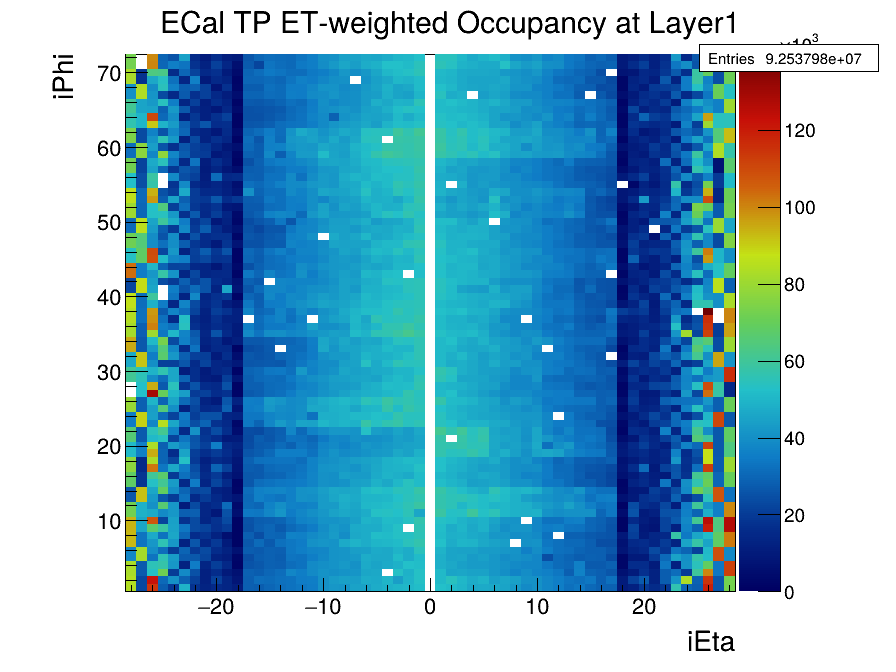


ecalOccRecdEtWgt  run=398191


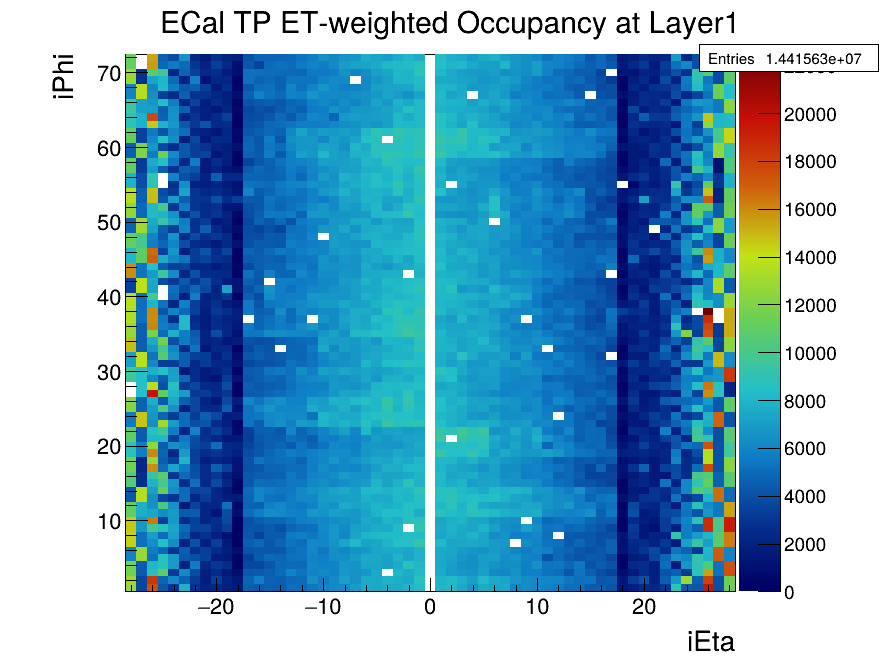


ecalOccRecdEtWgt  run=398194


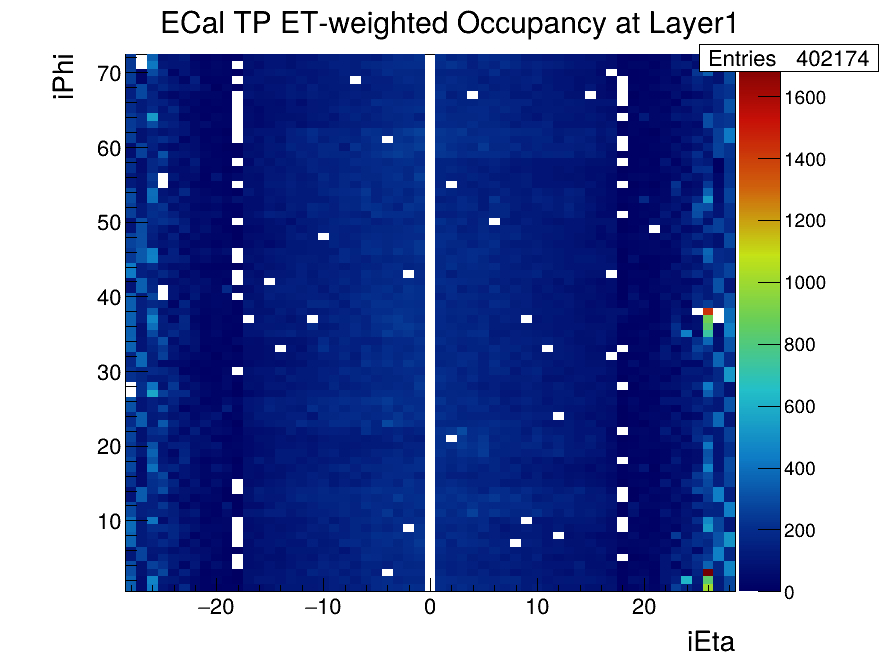


ecalOccRecdEtWgt  run=398199


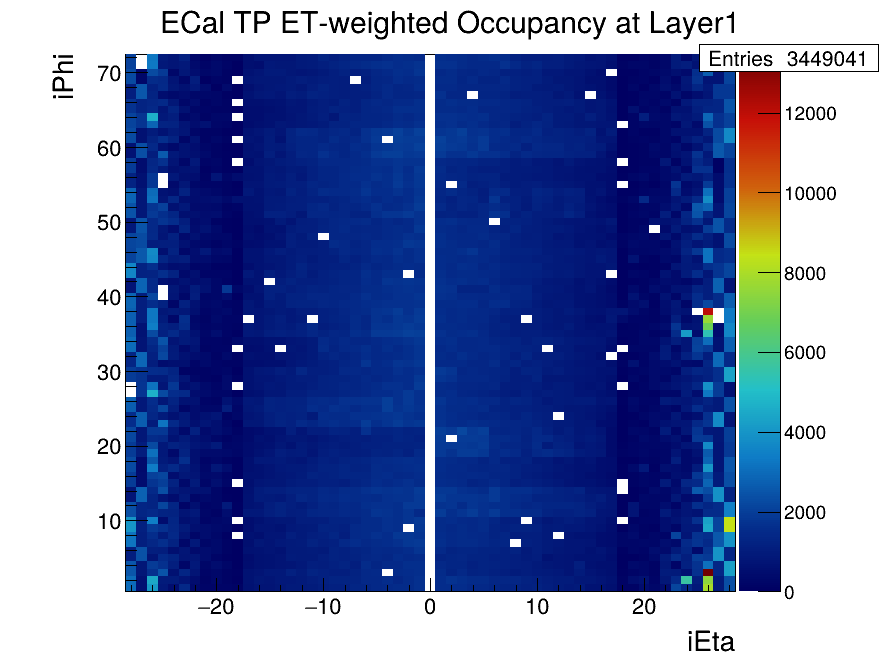

In [8]:
# ── Preview produced images inline ───────────────────────────────────────────
# Shows the first image per plot name across all runs
for plot_name in PLOT_CONFIG:
    subset = df[(df['plot_name'] == plot_name) & (df['out_png'].notna())]
    if subset.empty:
        print(f'{plot_name}: no images produced')
        continue
    for _, row in subset.iterrows():
        print(f"{plot_name}  run={row['run']}")
        display(Image(filename=row['out_png'], width=600))
        print()

In [9]:
# ── Show output tree ──────────────────────────────────────────────────────────
root = Path(OUTDIR)
for plot_dir in sorted(p for p in root.iterdir() if p.is_dir()):
    pngs = sorted(plot_dir.glob('*.png'))
    print(f'{plot_dir.name}/  ({len(pngs)} images)')
    for p in pngs:
        print(f'  {p.name}')

ecalOccRecdEtWgt/  (8 images)
  ecalOccRecdEtWgt_run398185.png
  ecalOccRecdEtWgt_run398186.png
  ecalOccRecdEtWgt_run398187.png
  ecalOccRecdEtWgt_run398188.png
  ecalOccRecdEtWgt_run398189.png
  ecalOccRecdEtWgt_run398191.png
  ecalOccRecdEtWgt_run398194.png
  ecalOccRecdEtWgt_run398199.png


In [ ]:
import re

# ── Reverse lookup: filename stem → path + description ───────────────────────
# Given any image filename, strip '_run<XXXXXX>.png' to get the stem,
# then call lookup_by_stem() to recover the ROOT path and description.

example_file = Path("images/L1T_00/L1T_00_run398185.png")
stem = re.sub(r"_run\d+$", "", example_file.stem)   # 'L1T_00'
info = lookup_by_stem(stem)
print(f"stem        : {stem}")
print(f"root_path   : {info['root_path'].format(run='398185')}")
print(f"description : {info['description']}")
print(f"subsystem   : {info['subsystem']}")
print(f"plot_number : {info['plot_number']}")
print(f"subplot     : {info['subplot']}")

# ── Reference images ──────────────────────────────────────────────────────────
# Copy a "good example" PNG into images/ref/ using the same stem + run:
#   images/ref/<stem>_run<XXXXXX>.png
# e.g. images/ref/L1T_00_run398185.png
# Pass it to query() as: reference_image="images/ref/L1T_00_run398185.png"